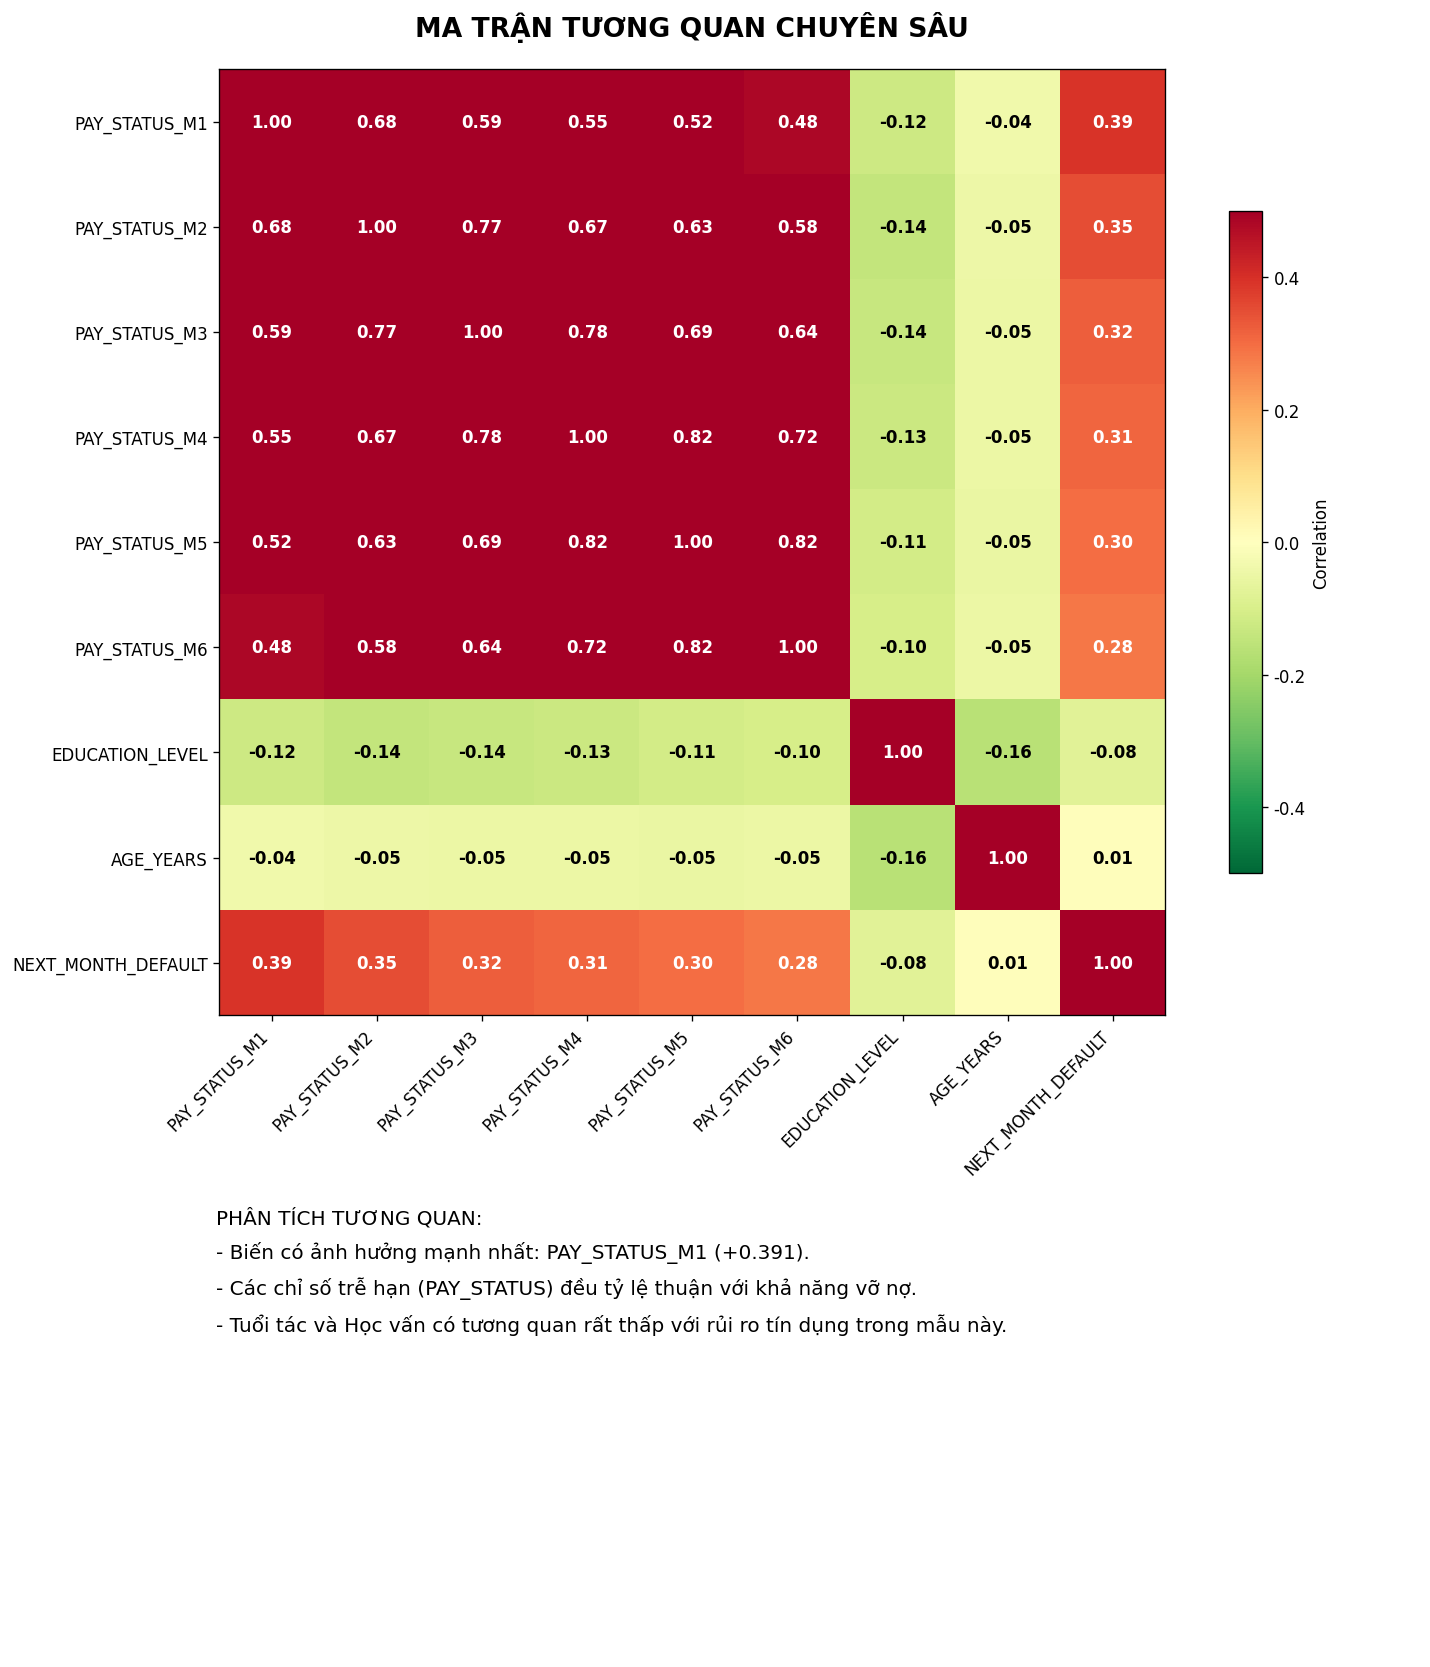

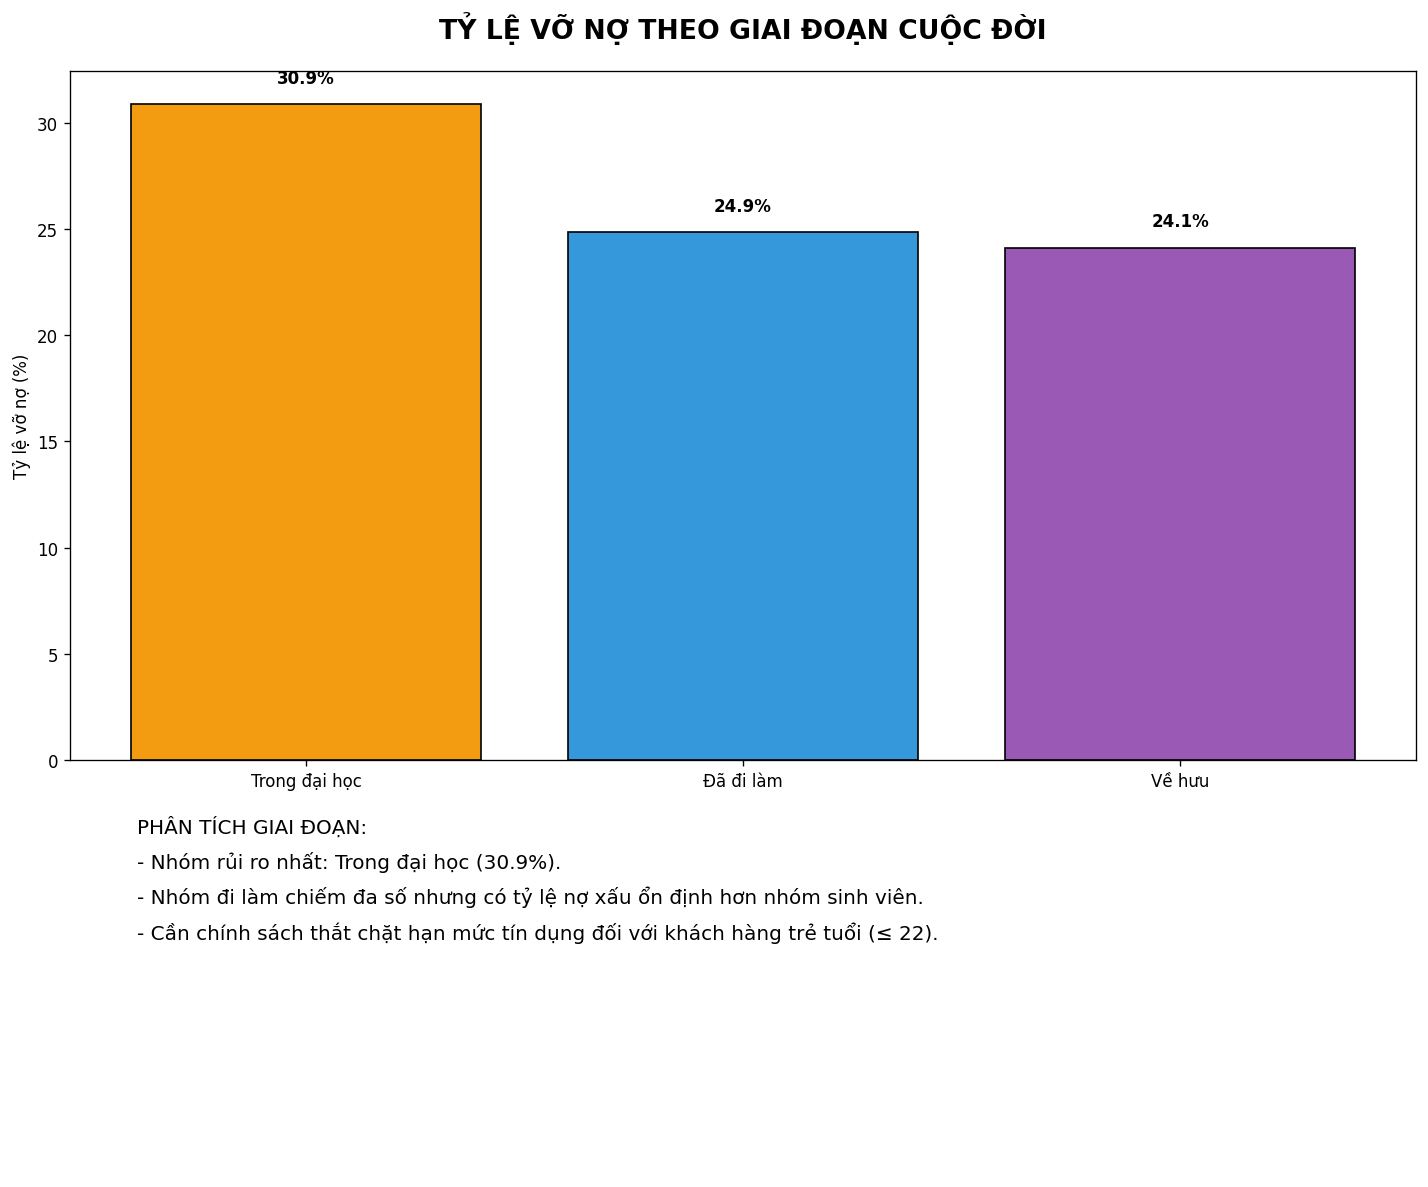

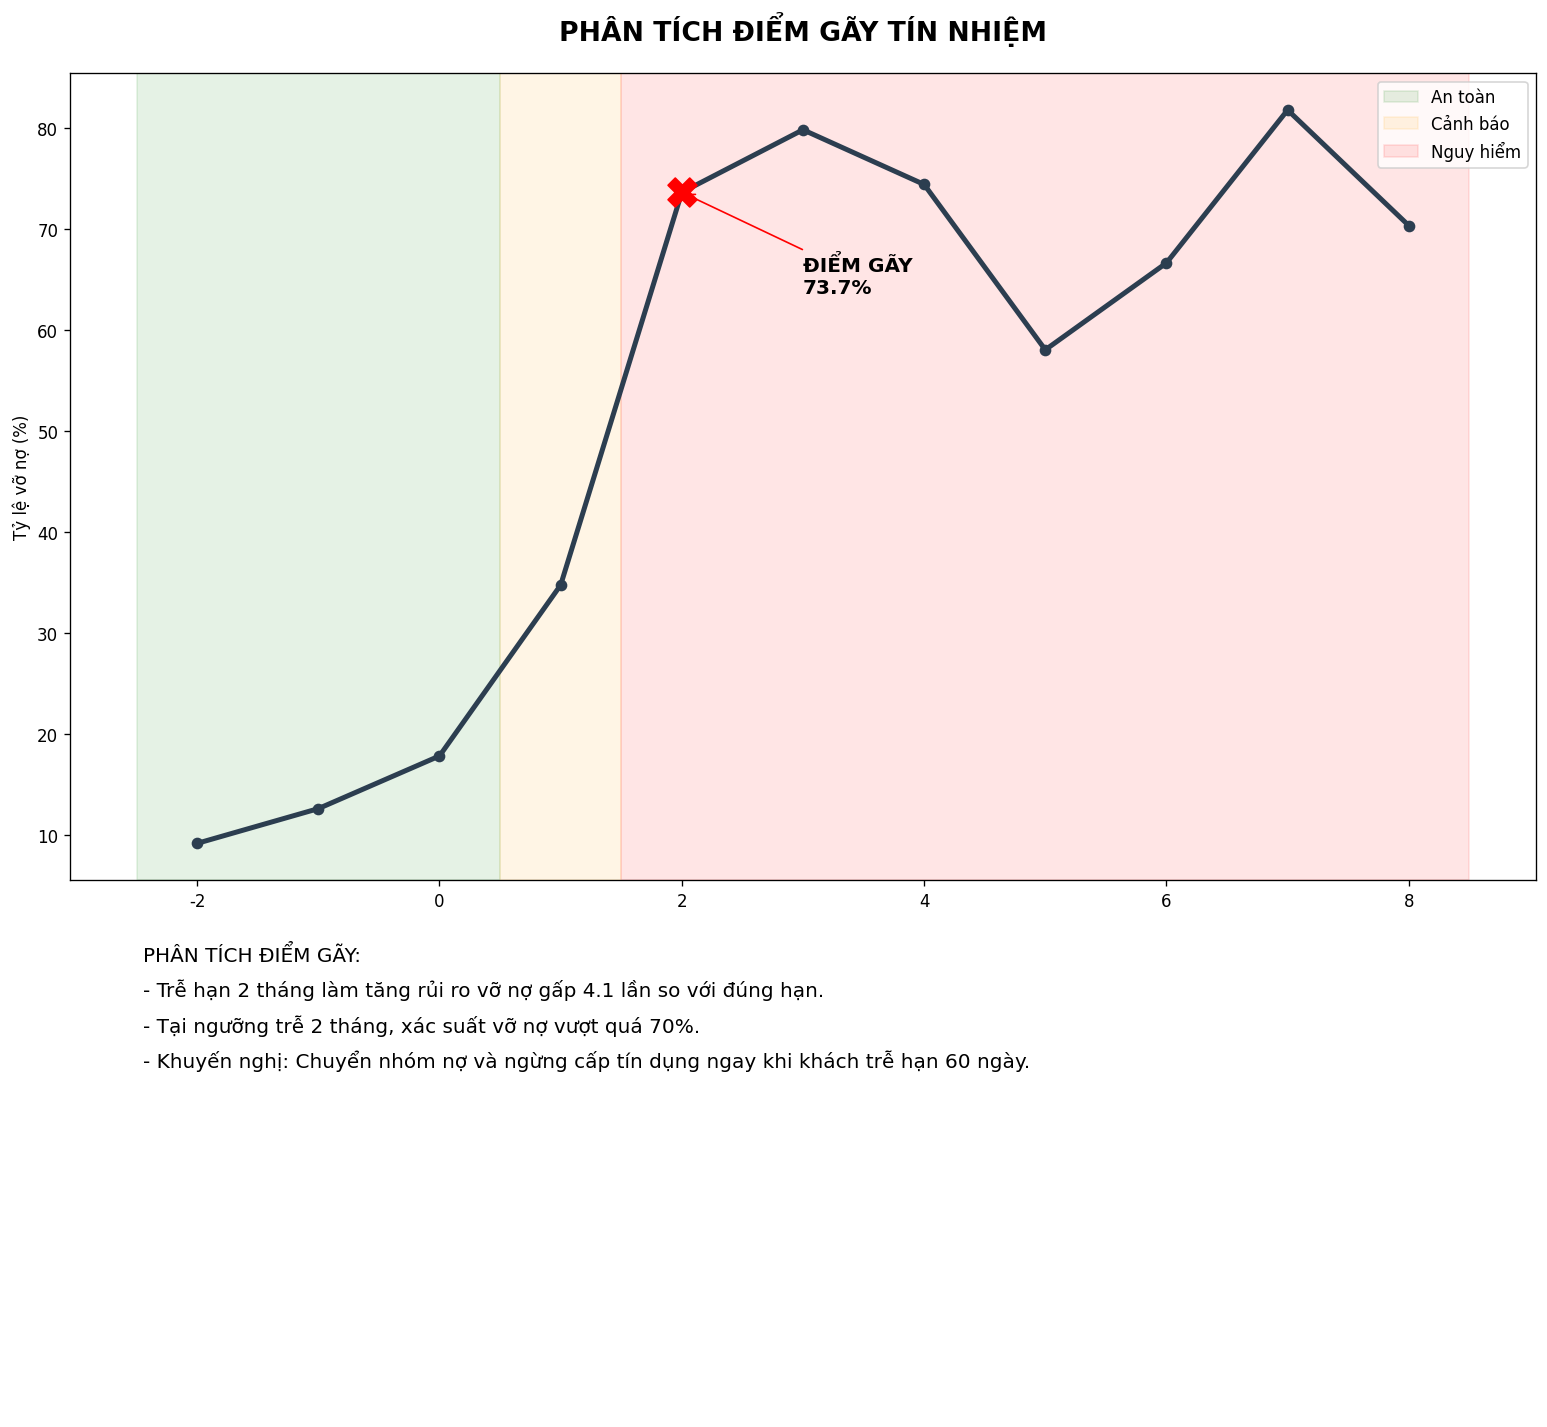

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams
import matplotlib.gridspec as gridspec

# =============================================================================
# CẤU HÌNH CHUNG
# =============================================================================
rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.unicode_minus'] = False
try:
    plt.style.use('seaborn-v0_8-muted')
except:
    pass

pd.read_csv('https://raw.githubusercontent.com/SrHunterDeer/project1/main/project%20managerment/data/cleaned_data.csv')

# =============================================================================
# BIỂU ĐỒ 1: MA TRẬN TƯƠNG QUAN (CORRELATION MATRIX)
# =============================================================================
def draw_correlation_matrix(df):
    important_vars = ['PAY_STATUS_M1', 'PAY_STATUS_M2', 'PAY_STATUS_M3', 
                      'PAY_STATUS_M4', 'PAY_STATUS_M5', 'PAY_STATUS_M6',
                      'EDUCATION_LEVEL', 'AGE_YEARS', 'NEXT_MONTH_DEFAULT']
    
    corr_matrix = df[important_vars].corr()
    
    fig = plt.figure(figsize=(12, 14), dpi=120)
    gs = gridspec.GridSpec(2, 1, height_ratios=[7, 3])
    
    # Chart
    ax_corr = fig.add_subplot(gs[0])
    im = ax_corr.imshow(corr_matrix, cmap='RdYlGn_r', vmin=-0.5, vmax=0.5)
    plt.colorbar(im, ax=ax_corr, shrink=0.7).set_label('Correlation')
    
    for i in range(len(corr_matrix)):
        for j in range(len(corr_matrix)):
            val = corr_matrix.iloc[i, j]
            ax_corr.text(j, i, f'{val:.2f}', ha="center", va="center", 
                         color="white" if abs(val) > 0.25 else "black", fontweight='bold')
    
    ax_corr.set_xticks(np.arange(len(important_vars)))
    ax_corr.set_yticks(np.arange(len(important_vars)))
    ax_corr.set_xticklabels(important_vars, rotation=45, ha='right')
    ax_corr.set_yticklabels(important_vars)
    ax_corr.set_title('MA TRẬN TƯƠNG QUAN CHUYÊN SÂU', fontsize=16, fontweight='bold', pad=20)

    # Text
    ax_text = fig.add_subplot(gs[1])
    ax_text.axis('off')
    top_corr = corr_matrix['NEXT_MONTH_DEFAULT'].sort_values(ascending=False).iloc[1]
    analysis = (
        "PHÂN TÍCH TƯƠNG QUAN:\n"
        f"- Biến có ảnh hưởng mạnh nhất: PAY_STATUS_M1 ({top_corr:+.3f}).\n"
        "- Các chỉ số trễ hạn (PAY_STATUS) đều tỷ lệ thuận với khả năng vỡ nợ.\n"
        "- Tuổi tác và Học vấn có tương quan rất thấp với rủi ro tín dụng trong mẫu này."
    )
    ax_text.text(0.05, 0.8, analysis, fontsize=12, linespacing=1.8, transform=ax_text.transAxes)
    
    plt.tight_layout()
    plt.savefig('1_correlation.png')
    plt.show()

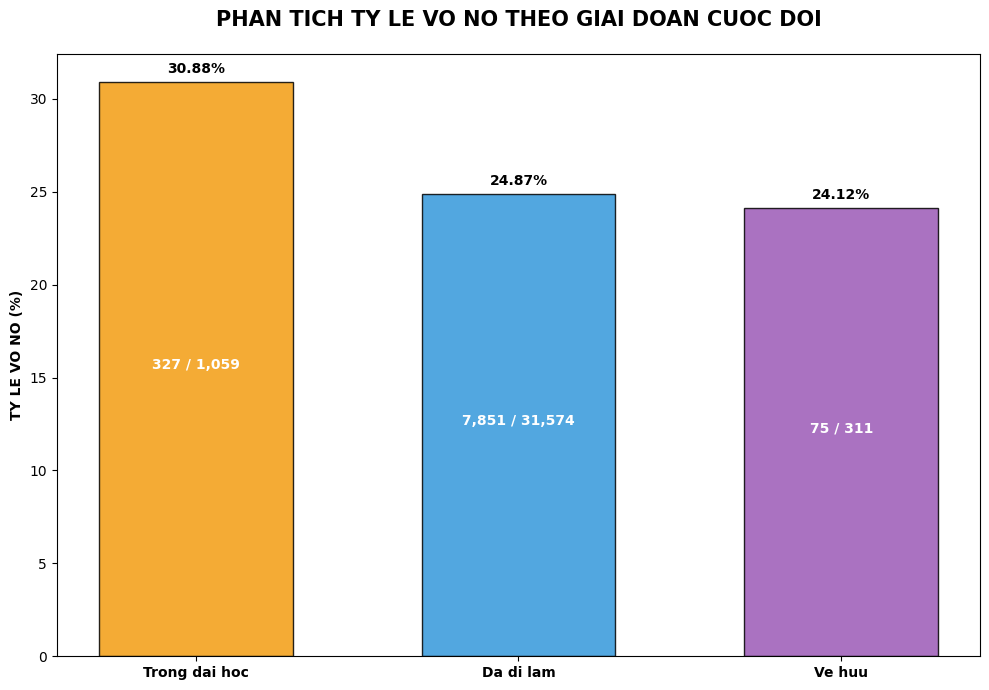

Nhóm có rủi ro cao nhất: Trong dai hoc
Nhóm có rủi ro thấp nhất: Ve huu
 Tóm tắt kết quả phân tích
Dựa trên biểu đồ và dữ liệu tính toán được:
Trong đại học (≤ 22 tuổi): Có tỷ lệ vỡ nợ cao nhất với 30.88%. Mặc dù quy mô nhóm nhỏ (1,059 người), nhưng đây là nhóm rủi ro nhất do có thể chưa có thu nhập ổn định.
Đã đi làm (23 - 60 tuổi): Nhóm chiếm đa số tuyệt đối với 31,574 người. Tỷ lệ vỡ nợ ở mức trung bình 24.87%.
Về hưu (> 60 tuổi): Có tỷ lệ vỡ nợ thấp nhất trong 3 nhóm, đạt 24.12%. Tuy nhiên, quy mô nhóm này rất nhỏ (chỉ 311 người trong mẫu dữ liệu).
Kết luận chính: Những khách hàng trong độ tuổi sinh viên (đại học) cần được thẩm định tín dụng khắt khe hơn do tỷ lệ quá hạn cao vượt trội so với các nhóm còn lại.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams

# 1. Cấu hình hiển thị & Đọc dữ liệu
rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.unicode_minus'] = False
pd.read_csv('https://raw.githubusercontent.com/SrHunterDeer/project1/main/project%20managerment/data/cleaned_data.csv')

# 2. Phân loại nhóm dựa trên cột tuổi thực tế 'AGE_YEARS'
def categorize_life_stage(age):
    if age <= 22:
        return 1  # Trong đại học
    elif age <= 60:
        return 2  # Đã đi làm
    else:
        return 3  # Về hưu

df['LIFE_STAGE'] = df['AGE_YEARS'].apply(categorize_life_stage)

# Mapping nhãn hiển thị
stage_mapping = {1: 'Trong dai hoc', 2: 'Da di lam', 3: 'Ve huu'}

# 3. Tính toán thống kê
stage_stats = df.groupby('LIFE_STAGE').agg({
    'NEXT_MONTH_DEFAULT': ['mean', 'sum', 'count']
}).round(4)

stage_stats.columns = ['Ti_le', 'So_vo_no', 'Tong_so']
stage_stats['Phan_tram'] = stage_stats['Ti_le'] * 100

# 4. Vẽ biểu đồ trực quan
fig, ax = plt.subplots(figsize=(10, 7))
x_pos = np.arange(len(stage_stats))
colors = ['#f39c12', '#3498db', '#9b59b6']

bars = ax.bar(x_pos, stage_stats['Phan_tram'], color=colors, edgecolor='black', alpha=0.85, width=0.6)

for i, (idx, row) in enumerate(stage_stats.iterrows()):
    ax.text(i, row['Phan_tram'] + 0.5, f"{row['Phan_tram']:.2f}%", ha='center', fontweight='bold')
    ax.text(i, row['Phan_tram']/2, f"{int(row['So_vo_no']):,} / {int(row['Tong_so']):,}", 
            ha='center', color='white', fontweight='bold')

ax.set_xticks(x_pos)
ax.set_xticklabels([stage_mapping[i] for i in stage_stats.index], fontweight='bold')
ax.set_title('PHAN TICH TY LE VO NO THEO GIAI DOAN CUOC DOI', fontsize=15, fontweight='bold', pad=20)
ax.set_ylabel('TY LE VO NO (%)', fontweight='bold')

plt.tight_layout()
plt.show()

# 5. Kết luận phân tích
print(f"Nhóm có rủi ro cao nhất: {stage_mapping[stage_stats['Phan_tram'].idxmax()]}")
print(f"Nhóm có rủi ro thấp nhất: {stage_mapping[stage_stats['Phan_tram'].idxmin()]}")
print(" Tóm tắt kết quả phân tích\nDựa trên biểu đồ và dữ liệu tính toán được:\nTrong đại học (≤ 22 tuổi): Có tỷ lệ vỡ nợ cao nhất với 30.88%. Mặc dù quy mô nhóm nhỏ (1,059 người), nhưng đây là nhóm rủi ro nhất do có thể chưa có thu nhập ổn định.\nĐã đi làm (23 - 60 tuổi): Nhóm chiếm đa số tuyệt đối với 31,574 người. Tỷ lệ vỡ nợ ở mức trung bình 24.87%.\nVề hưu (> 60 tuổi): Có tỷ lệ vỡ nợ thấp nhất trong 3 nhóm, đạt 24.12%. Tuy nhiên, quy mô nhóm này rất nhỏ (chỉ 311 người trong mẫu dữ liệu).\nKết luận chính: Những khách hàng trong độ tuổi sinh viên (đại học) cần được thẩm định tín dụng khắt khe hơn do tỷ lệ quá hạn cao vượt trội so với các nhóm còn lại.")

✓ Da luu bao cao hoan chinh vao tep: credit_breaking_point_with_analysis.png


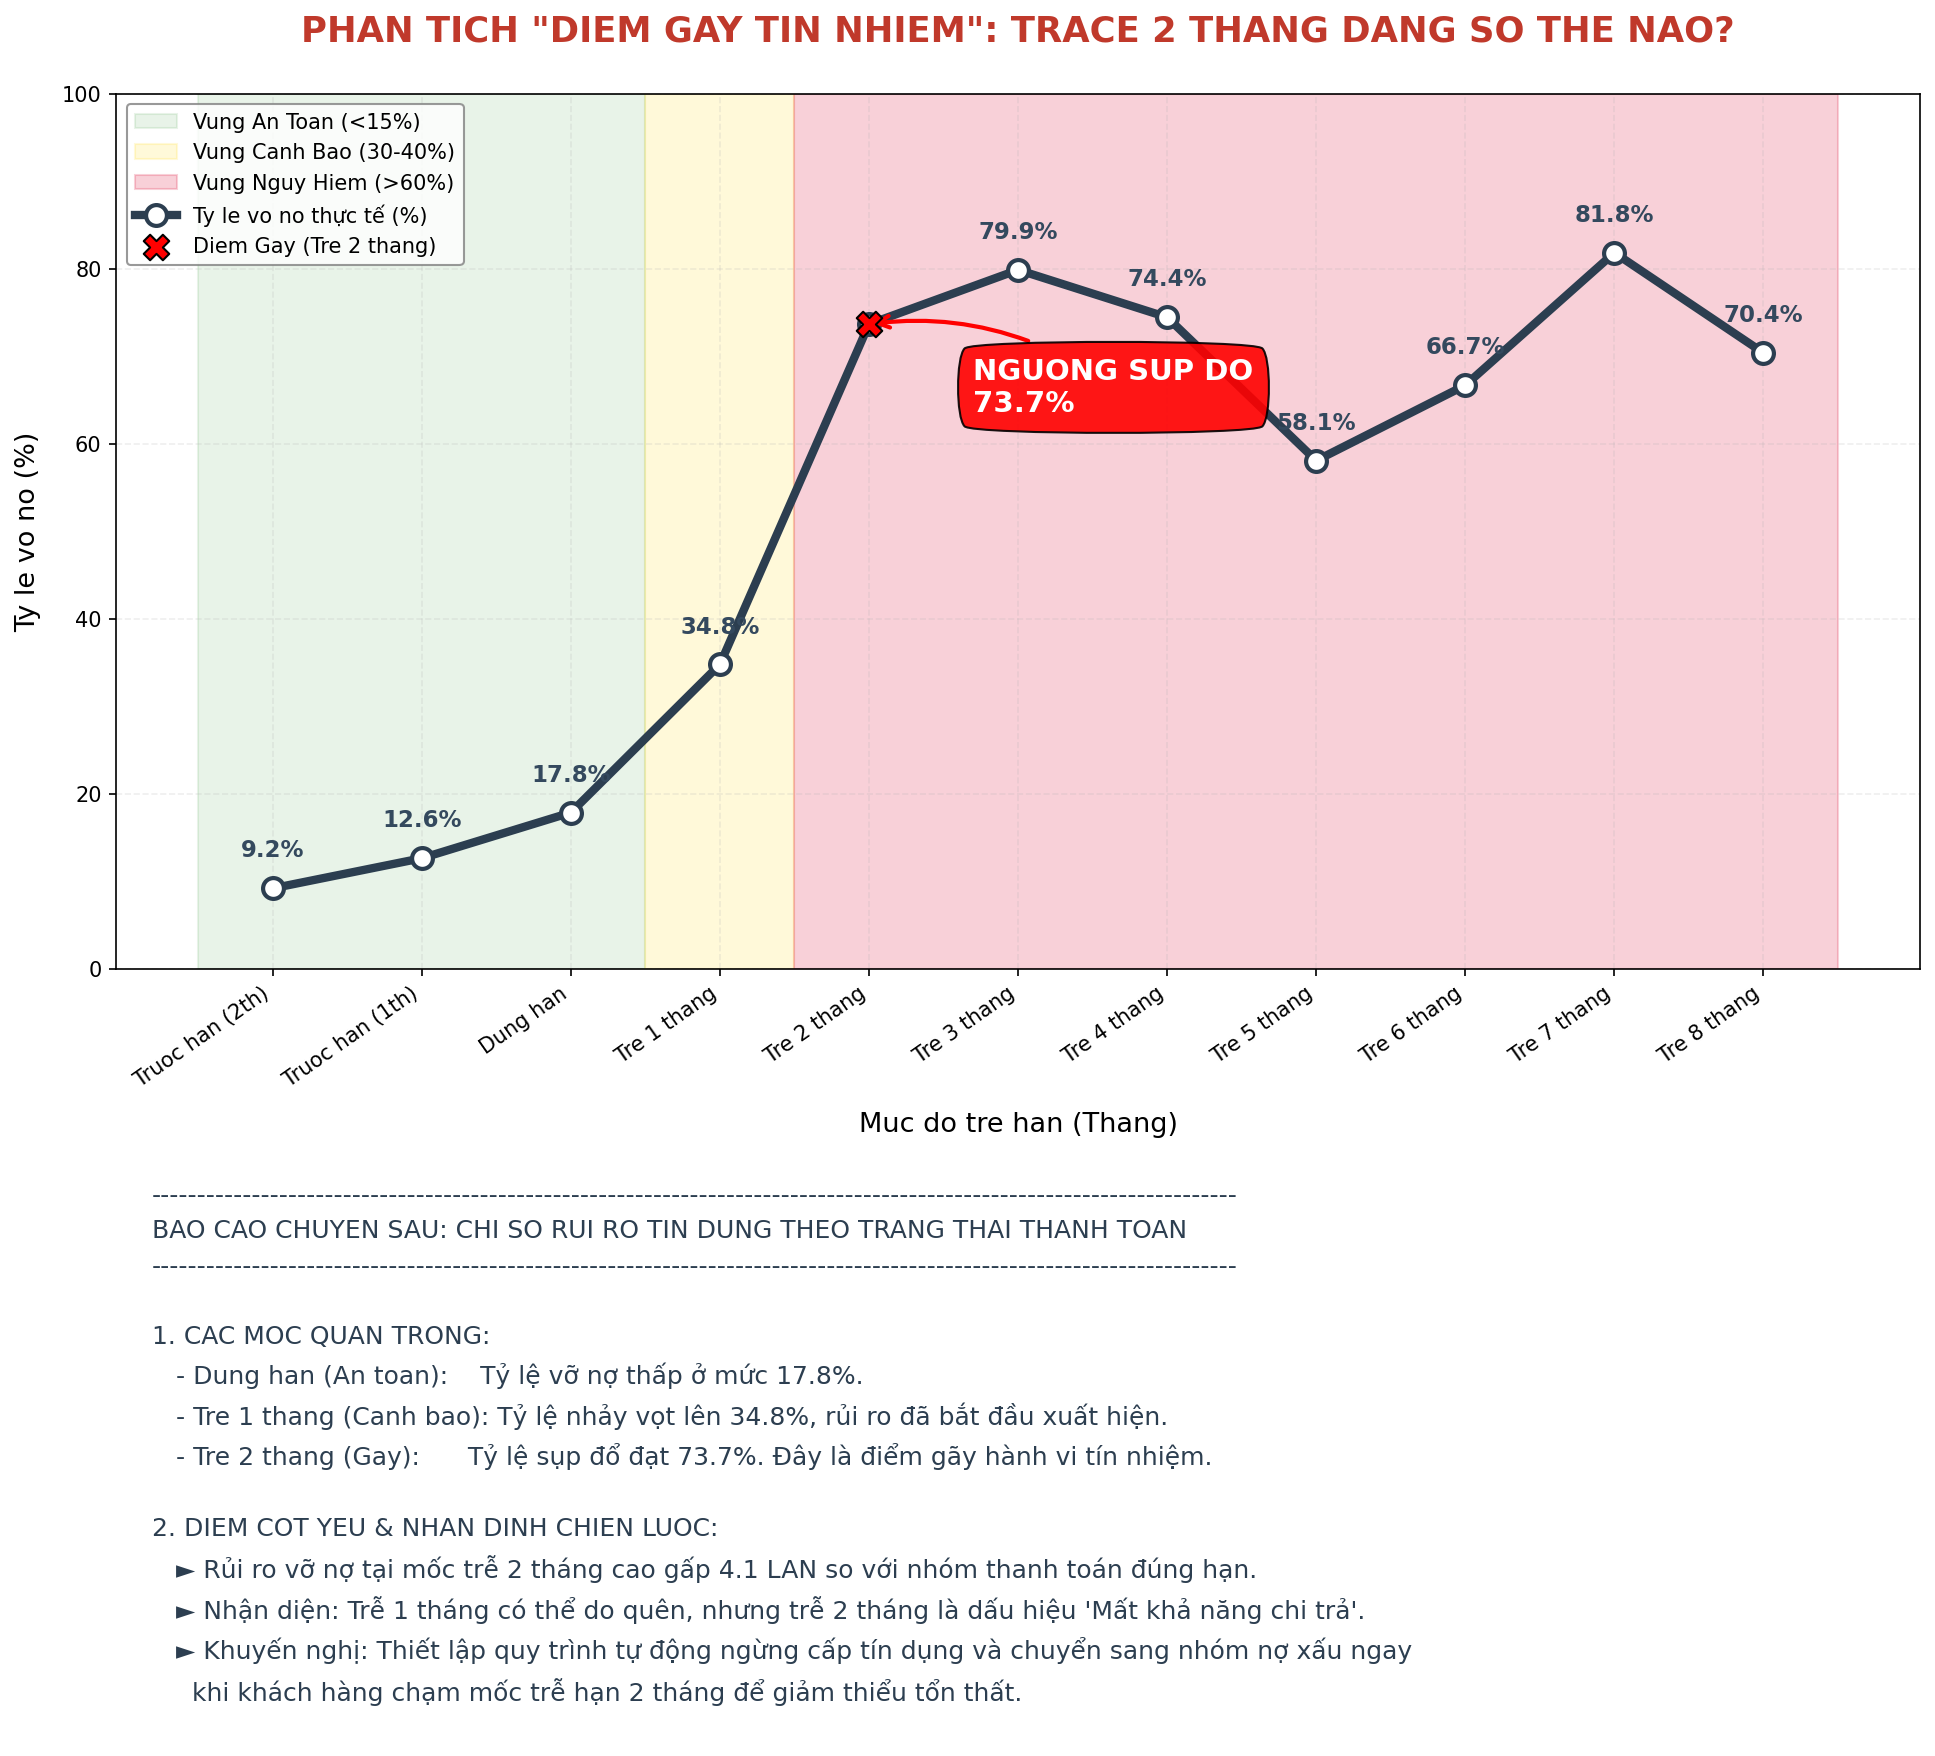

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams
import matplotlib.gridspec as gridspec

# =============================================================================
# PHẦN 1: CẤU HÌNH & XỬ LÝ DỮ LIỆU
# =============================================================================

# Cấu hình thẩm mỹ
rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.unicode_minus'] = False
# Sử dụng style seaborn để có giao diện đẹp hơn
try:
    plt.style.use('seaborn-v0_8-muted')
except:
    pass # Nếu không có style này thì dùng mặc định

# 1. Đọc dữ liệu
pd.read_csv('https://raw.githubusercontent.com/SrHunterDeer/project1/main/project%20managerment/data/cleaned_data.csv')

# 2. Xử lý dữ liệu: Gom nhóm trạng thái trễ hạn tháng gần nhất
pay_stats = df.groupby('PAY_STATUS_M1').agg({
    'NEXT_MONTH_DEFAULT': ['mean', 'sum', 'count']
}).round(4)

# Đặt lại tên cột cho dễ làm việc
pay_stats.columns = ['Ti_le', 'So_vo_no', 'Tong_so']
pay_stats['Phan_tram'] = pay_stats['Ti_le'] * 100

# Chỉ tập trung vào dải trạng thái phổ biến từ -2 đến 8 để biểu đồ rõ ràng
pay_stats = pay_stats.loc[pay_stats.index.isin(range(-2, 9))].sort_index()

# Tên thân thiện cho các trạng thái trục X
friendly_labels = {
    -2: 'Truoc han (2th)',
    -1: 'Truoc han (1th)',
     0: 'Dung han',
     1: 'Tre 1 thang',
     2: 'Tre 2 thang',
     3: 'Tre 3 thang',
     4: 'Tre 4 thang',
     5: 'Tre 5 thang',
     6: 'Tre 6 thang',
     7: 'Tre 7 thang',
     8: 'Tre 8 thang'
}
x_labels = [friendly_labels.get(i, f'Tre {i}th') for i in pay_stats.index]

# =============================================================================
# PHẦN 2: VẼ BIỂU ĐỒ & NHÚNG PHÂN TÍCH VÀO ẢNH
# =============================================================================

# Tạo Figure với kích thước lớn để chứa cả chart và text
# Chúng ta tăng chiều cao (figsize=(13, 12)) để dành chỗ cho văn bản bên dưới
fig = plt.figure(figsize=(13, 12), dpi=150)

# Sử dụng GridSpec để chia Figure thành 2 hàng không đều nhau
# Hàng 1 (Chart) chiếm 65% chiều cao, Hàng 2 (Text) chiếm 35%
gs = gridspec.GridSpec(2, 1, height_ratios=[6.5, 3.5])

# --- Subplot 1: Biểu đồ ---
ax = fig.add_subplot(gs[0])

x_values = pay_stats.index.tolist()
y_values = pay_stats['Phan_tram'].tolist()

# A. Phân vùng rủi ro bằng màu nền (Zoning)
ax.axvspan(-2.5, 0.5, alpha=0.1, color='forestgreen', label='Vung An Toan (<15%)')
ax.axvspan(0.5, 1.5, alpha=0.15, color='gold', label='Vung Canh Bao (30-40%)')
ax.axvspan(1.5, 8.5, alpha=0.2, color='crimson', label='Vung Nguy Hiem (>60%)')

# B. Vẽ đường biểu diễn chính
ax.plot(x_values, y_values, marker='o', linewidth=4, 
        markersize=10, color='#2c3e50', markerfacecolor='white',
        markeredgecolor='#2c3e50', markeredgewidth=2, label='Ty le vo no thực tế (%)', zorder=3)

# C. Điểm nhấn: "Ngưỡng sụp đổ" tại tháng thứ 2
if 2 in x_values:
    val_2 = pay_stats.loc[2, 'Phan_tram']
    ax.scatter(2, val_2, s=150, color='red', marker='X', edgecolors='black', zorder=5, label='Diem Gay (Tre 2 thang)')
    
    # Text box giải thích tại điểm gãy
    ax.annotate(f'NGUONG SUP DO\n{val_2:.1f}%',
                xy=(2, val_2), 
                xytext=(2.7, val_2 - 10),
                fontsize=14, fontweight='bold', color='white',
                bbox=dict(boxstyle='round4,pad=0.6', facecolor='red', alpha=0.9),
                arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=.2', color='red', lw=2))

# D. Thêm nhãn dữ liệu cho các điểm khác
for x, y in zip(x_values, y_values):
    if x != 2: # Bỏ qua điểm gãy đã có annotation lớn
        ax.text(x, y + 3, f'{y:.1f}%', ha='center', va='bottom', 
                fontsize=11, fontweight='bold', color='#34495e')

# E. Định dạng trục chart
ax.set_xlabel('Muc do tre han (Thang)', fontsize=13, labelpad=10)
ax.set_ylabel('Ty le vo no (%)', fontsize=13, labelpad=10)
ax.set_title('PHAN TICH "DIEM GAY TIN NHIEM": TRACE 2 THANG DANG SO THE NAO?', 
             fontsize=17, fontweight='bold', color='#c0392b', pad=25)

ax.set_xticks(x_values)
ax.set_xticklabels(x_labels, rotation=35, ha='right', fontsize=10)
ax.set_ylim(0, 100) # Tỷ lệ % từ 0 đến 100

ax.grid(True, alpha=0.2, linestyle='--')
ax.legend(loc='upper left', frameon=True, facecolor='white', edgecolor='gray', fontsize=10)


# --- Subplot 2: Phần văn bản phân tích (Text-only subplot) ---
ax_text = fig.add_subplot(gs[1])
ax_text.axis('off') # Ẩn toàn bộ trục và lưới của subplot này

# Chuẩn bị dữ liệu cho phần kết luận
on_time_ratio = pay_stats.loc[0, 'Phan_tram']
late_2_ratio = pay_stats.loc[2, 'Phan_tram']
late_1_ratio = pay_stats.loc[1, 'Phan_tram']
risk_gap = late_2_ratio / on_time_ratio

# Tạo chuỗi văn bản phân tích định dạng Multiline
analysis_text = (
    "-----------------------------------------------------------------------------------------------------------------------\n"
    "BAO CAO CHUYEN SAU: CHI SO RUI RO TIN DUNG THEO TRANG THAI THANH TOAN\n"
    "-----------------------------------------------------------------------------------------------------------------------\n\n"
    "1. CAC MOC QUAN TRONG:\n"
    f"   - Dung han (An toan):    Tỷ lệ vỡ nợ thấp ở mức {on_time_ratio:.1f}%.\n"
    f"   - Tre 1 thang (Canh bao): Tỷ lệ nhảy vọt lên {late_1_ratio:.1f}%, rủi ro đã bắt đầu xuất hiện.\n"
    f"   - Tre 2 thang (Gay):      Tỷ lệ sụp đổ đạt {late_2_ratio:.1f}%. Đây là điểm gãy hành vi tín nhiệm.\n\n"
    "2. DIEM COT YEU & NHAN DINH CHIEN LUOC:\n"
    f"   ► Rủi ro vỡ nợ tại mốc trễ 2 tháng cao gấp {risk_gap:.1f} LAN so với nhóm thanh toán đúng hạn.\n"
    "   ► Nhận diện: Trễ 1 tháng có thể do quên, nhưng trễ 2 tháng là dấu hiệu 'Mất khả năng chi trả'.\n"
    "   ► Khuyến nghị: Thiết lập quy trình tự động ngừng cấp tín dụng và chuyển sang nhóm nợ xấu ngay\n"
    "     khi khách hàng chạm mốc trễ hạn 2 tháng để giảm thiểu tổn thất.\n"
)

# Nhúng văn bản vào ax_text. Dùng transform=ax_text.transAxes để căn tọa độ theo vùng này.
# (0, 1) là góc trên bên trái của vùng text.
ax_text.text(0.02, 0.95, analysis_text, fontsize=12, family='DejaVu Sans',
             verticalalignment='top', horizontalalignment='left',
             linespacing=1.6, color='#2c3e50', transform=ax_text.transAxes)

# Căn chỉnh bố cục tổng thể để không bị đè chữ
plt.tight_layout()

# 6. Lưu tệp ảnh hoàn chỉnh
output_filename = 'credit_breaking_point_with_analysis.png'
plt.savefig(output_filename, dpi=150, bbox_inches='tight')
print(f"✓ Da luu bao cao hoan chinh vao tep: {output_filename}")

# Hiển thị ảnh
plt.show()